Project: DeepFER – Facial Emotion Recognition Using Deep Learning




Before we start working with the dataset, we need to import the Python libraries that will help us read images, perform calculations, create graphs, and work with folders.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Import Image Processing Libraries

Objective

Our dataset contains images, not numbers or text. We need special libraries to:

Read images from folders
Resize images
Convert images into arrays
Prepare them for the CNN model



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import cv2

STEP 3: Import Additional Libraries
Objective

Before loading the dataset, we need a few more libraries that help us:

Display images
Count images in folders
Create graphs
Handle random selections

In [1]:
import random
from PIL import Image

STEP 4: Upload and Extract the Dataset
Objective

Now we need to upload the emotion dataset ZIP file and extract it so Python can access all the images.

In [5]:
from google.colab import files

uploaded = files.upload()

Saving images-20260804T164954Z-1-001.zip to images-20260804T164954Z-1-001.zip


In [6]:
import os

print(os.listdir())

['.config', 'images-20260804T164954Z-1-001.zip', 'sample_data']


Step 4.2: Check the Uploaded Filename

In [5]:
import os

print(os.listdir())

Step 4.3: Use the Correct Filename

In [7]:
import zipfile

zip_file = "images-20260804T164954Z-1-001.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


Step 5: Find the Correct Folder


In [13]:
import os

print(os.listdir("/content"))

['.config', 'dataset', 'images-20260804T164954Z-1-001.zip', 'sample_data']


STEP 5.2: Check What's Inside the dataset Folder
 Objective

Now we want to see what is inside the dataset folder.

In [20]:
print(os.listdir("/content/dataset"))

['images']


STEP 5.3: Check What's Inside the images Folder
Objective

Now we want to see what is inside the images folder.

In [21]:
print(os.listdir("/content/dataset/images"))

['archive-3.zip']


STEP 5.4: Extract the Second ZIP File
 Objective

Extract the archive-3.zip file so we can access the train and test folders.

In [22]:
import zipfile

zip_path = "/content/dataset/images/archive-3.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset/images")

print("Second ZIP extracted successfully!")

Second ZIP extracted successfully!


STEP 5.5: Verify the Dataset
 Objective

Now we will check whether the train and test folders are present.

In [23]:
import os

print(os.listdir("/content/dataset/images"))

['archive-3', '__MACOSX', 'archive-3.zip']


STEP 5.6: Check Inside archive-3
Objective

Now let's see what's inside the archive-3 folder.

In [24]:
import os

print(os.listdir("/content/dataset/images/archive-3"))

['test', 'train']


STEP 6: Set the Train and Test Paths
Objective

Now we'll save the locations of the train and test folders in variables.

Instead of writing the full path every time, we'll save it once and use it throughout the project.

In [25]:
train_path = "/content/dataset/images/archive-3/train"
test_path = "/content/dataset/images/archive-3/test"

print("Train Path:", train_path)
print("Test Path:", test_path)

Train Path: /content/dataset/images/archive-3/train
Test Path: /content/dataset/images/archive-3/test


STEP 7: Find All Emotion Classes
Objective

Before training the model, we need to know what emotion categories (classes) are present in the dataset.

A class is simply a category that the model will learn to recognize.

For example:

Happy 😊
Sad 😢

In [26]:
emotion_classes = os.listdir(train_path)

print("Emotion Classes:")
print(emotion_classes)

Emotion Classes:
['fear', 'disgust', 'surprise', 'neutral', 'happy', 'angry', 'sad']


STEP 7 Explanation
 Objective

Find all the emotion categories in the training dataset.

In [27]:
emotion_classes = os.listdir(train_path)

print("Emotion Classes:")
print(emotion_classes)

Emotion Classes:
['fear', 'disgust', 'surprise', 'neutral', 'happy', 'angry', 'sad']


STEP 8: Count the Number of Images in Each Emotion Class
Objective

Now we want to know how many images are available for each emotion.

This helps us understand whether the dataset is balanced.

In [28]:
for emotion in emotion_classes:
    folder_path = os.path.join(train_path, emotion)
    image_count = len(os.listdir(folder_path))
    print(f"{emotion}: {image_count} images")

fear: 4097 images
disgust: 436 images
surprise: 3171 images
neutral: 4965 images
happy: 7215 images
angry: 3995 images
sad: 4830 images


STEP 9: Count the Number of Images in Each Emotion Class
Objective

Before training a deep learning model, we need to know:

How many emotion classes exist?
How many images are in each class?
Is the dataset balanced?

This is an important EDA step because an imbalanced dataset can affect model performance.

In [29]:
for emotion in emotion_classes:
    folder_path = os.path.join(train_path, emotion)
    image_count = len(os.listdir(folder_path))
    print(f"{emotion}: {image_count} images")

fear: 4097 images
disgust: 436 images
surprise: 3171 images
neutral: 4965 images
happy: 7215 images
angry: 3995 images
sad: 4830 images


STEP 9: Display Sample Images
 Objective

Now we will display one sample image from each emotion class.

This helps us visually inspect the dataset before training the model.

In [32]:
import matplotlib.pyplot as plt
import random
from PIL import Image
import os

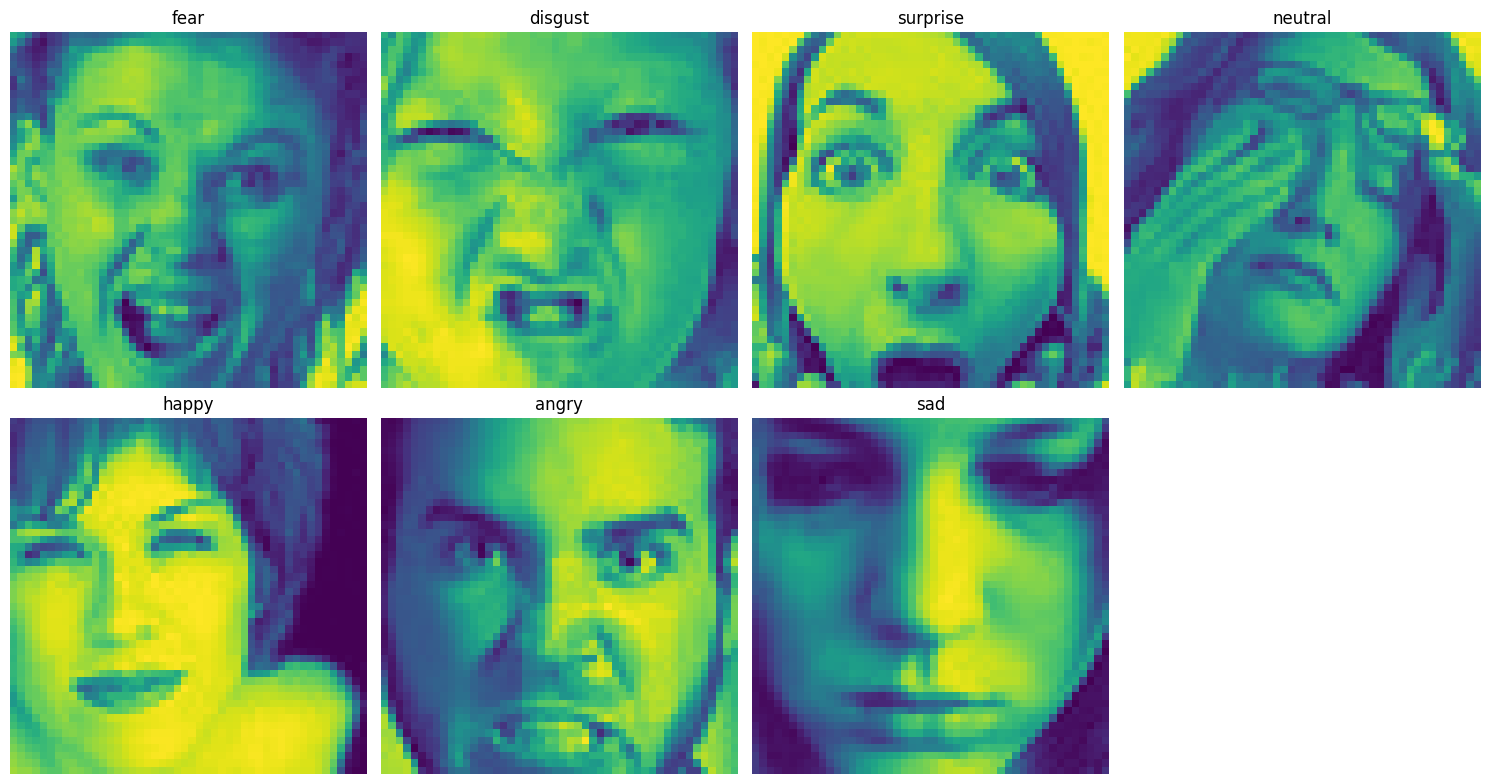

In [34]:

plt.figure(figsize=(15, 8))

for i, emotion in enumerate(emotion_classes):
    folder_path = os.path.join(train_path, emotion)
    image_name = random.choice(os.listdir(folder_path))
    image_path = os.path.join(folder_path, image_name)

    img = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(emotion)
    plt.axis("off")

plt.tight_layout()
plt.show()

STEP 10: Create the ImageDataGenerator
 Objective

Before giving images to the CNN model, we need to preprocess them.

We will:

Read images from folders.
Resize them.
Normalize pixel values.
Prepare them in batches for training.

Instead of doing all this manually, TensorFlow provides ImageDataGenerator.

In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

STEP 11: Load the Training and Testing Dataset
 Objective

Now we will load the images from the train and test folders.

We are not training the model yet.

We are simply telling TensorFlow:

"My images are in these folders. Please read them, resize them, and prepare them for the CNN."

In [36]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


STEP 12: Build the CNN Model (Part 1)
 Objective

Create the CNN model that will learn patterns from facial images and classify them into one of the 7 emotions.

---



In [37]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

STEP 12.2: Create the CNN Model and Add the First Layer
Objective

We will:

Create an empty CNN model.
Add the first Convolution Layer (Conv2D).

This is where the model starts learning features from facial images.

In [39]:
from tensorflow.keras.layers import Input

model = Sequential()

model.add(Input(shape=(48,48,1)))

model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu'
))

STEP 12.3: Add the First MaxPooling Layer
Objective

After the CNN detects important features using the Conv2D layer, we use MaxPooling2D to:

Reduce the image size.
Keep the most important features.
Reduce computation.
Help prevent overfitting.

In [40]:
model.add(MaxPooling2D(
    pool_size=(2,2)
))

STEP 12.4: Add the Second Convolution Layer
 Objective

The first Conv2D layer learns basic features like:

Edges
Lines
Eyes
Nose
Mouth

The second Conv2D layer learns more complex features by combining what the first layer found, such as:

Smiling faces
Angry eyebrows
Open mouth (surprise)

In [41]:
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

STEP 12.5: Add the Second MaxPooling Layer
Objective

After the second convolution layer extracts more complex facial features, we again reduce the feature map size using MaxPooling2D.

This helps:

Reduce computation.
Reduce memory usage.
Keep only the most important features.

In [42]:
model.add(MaxPooling2D(
    pool_size=(2,2)
))

STEP 12.6: Add the Flatten Layer
Objective

Until now, the CNN has been extracting features from the images.

Before sending these features to the final classifier (Dense layer), we need to convert them into a single 1D vector.

This is the job of the Flatten layer.

In [43]:
model.add(Flatten())

STEP 12.7: Add the First Dense Layer
bjective

The CNN has extracted features like:

Eyes
Nose
Mouth
Eyebrows
Smile
Facial patterns

Now the Dense layer learns from these features and helps classify the emotion.

In [44]:
model.add(Dense(
    units=128,
    activation='relu'
))

STEP 12.8: Add the Dropout Layer
Objective

Prevent the CNN from overfitting.

In [45]:
model.add(Dropout(
    rate=0.5
))

STEP 12.9: Add the Output Layer
Objective

This is the final layer of the CNN.

It predicts which emotion the face belongs to.

In [46]:
model.add(Dense(
    units=7,
    activation='softmax'
))

STEP 13: Compile the Model
 Objective

Building the model is like building a car.

Now we need to tell it:

How to learn? → Optimizer
How to measure mistakes? → Loss Function
How to evaluate performance? → Metrics

This process is called Compiling the Model.

In [47]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

STEP 14: Display the Model Architecture
 Objective

Now we will print the complete CNN architecture.

This helps us:

Verify that all layers are added correctly.
See the output shape after each layer.
Check the number of trainable parameters.

This is one of the most frequently asked interview questions.

In [48]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,047 (3.20 MB)

 Trainable params: 839,047 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

STEP 15: Train the CNN Model
Objective

Now we will train the CNN using the training dataset.

During training, the CNN will:

Learn facial features.
Reduce its mistakes.

In [49]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20
)

Epoch 1/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 103s 113ms/step - accuracy: 0.3403 - loss: 1.6634 - val_accuracy: 0.4231 - val_loss: 1.5151
Epoch 2/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 106s 119ms/step - accuracy: 0.4291 - loss: 1.4797 - val_accuracy: 0.4668 - val_loss: 1.3827
Epoch 3/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 99s 110ms/step - accuracy: 0.4647 - loss: 1.3973 - val_accuracy: 0.4933 - val_loss: 1.3188
Epoch 4/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 99s 110ms/step - accuracy: 0.4894 - loss: 1.3346 - val_accuracy: 0.5007 - val_loss: 1.2943
Epoch 5/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 100s 111ms/step - accuracy: 0.5147 - loss: 1.2687 - val_accuracy: 0.5135 - val_loss: 1.2542
Epoch 6/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 141s 110ms/step - accuracy: 0.5301 - loss: 1.2243 - val_accuracy: 0.5195 - val_loss: 1.2367
Epoch 7/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 98s 109ms/step - accuracy: 0.5511 - loss: 1.1758 - val_accuracy: 0.5256 - val_loss: 1.2285
Epoch 8/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 103s 114ms/step - accuracy: 0.5666 - lo

STEP 16: Plot Accuracy Graph
Objective

After training, we want to see:

How the training accuracy changed.
How the validation accuracy changed.
Whether the model learned well.

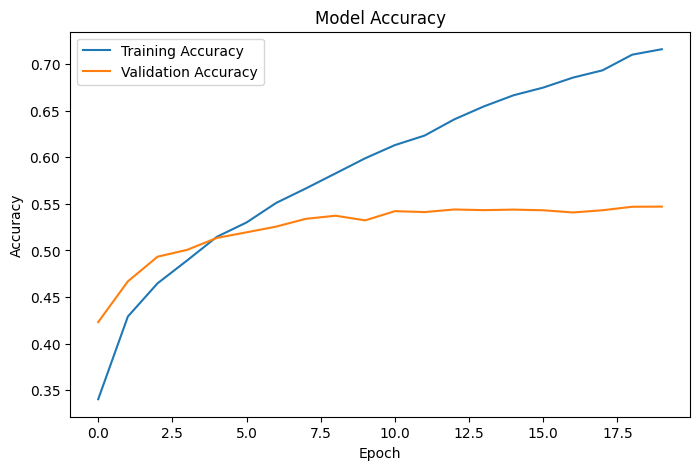

In [50]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

STEP 17: Plot Loss Graph
Objective

Now we will see whether the model's loss decreases during training.

Lower loss means the model is making fewer mistakes.

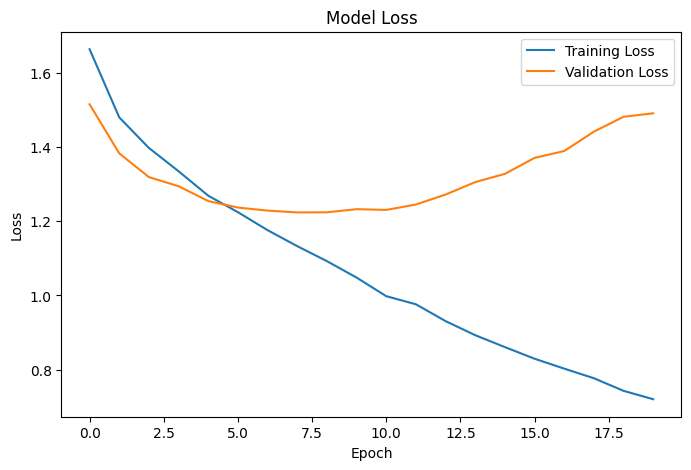

In [51]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

STEP 18: Evaluate the Model

Now let's find the final test accuracy and test loss.

In [52]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.5471 - loss: 1.4907
Test Loss: 1.4906889200210571
Test Accuracy: 0.5470883250236511


STEP 19: Save the trained model

In [53]:
model.save("emotion_detection_model.keras")

STEP 19: Save the Trained Model

Now we will save the trained model so you can use it later without retraining.

In [54]:
model.save("emotion_detection_model.keras")

print("Model saved successfully!")

Model saved successfully!


STEP 20: Verify That the Model Was Saved

In [55]:
import os

print(os.listdir())

['.config', 'dataset', 'images-20260804T164954Z-1-001.zip', 'emotion_detection_model.keras', 'sample_data']


STEP 21: Download the Model

In [56]:
from google.colab import files

files.download("emotion_detection_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Step 22.1: Load the Saved Model

In [57]:
from tensorflow.keras.models import load_model

model = load_model("emotion_detection_model.keras")

Step 22.2: Preprocess the Image

We'll resize it to 48×48, convert it to grayscale, normalize the pixel values, and prepare it for prediction.

In [62]:
img = Image.open("komala.avif/content/").convert("L")

Step 22.3: Predict the Emotion

In [64]:
print(img.size)

(600, 400)


In [69]:
import os

print(os.listdir("/content"))

['.config', 'dataset', 'komala.avif', 'images-20260804T164954Z-1-001.zip', 'emotion_detection_model.keras', 'sample_data']


In [70]:
from google.colab import files

uploaded = files.upload()

Saving komala.avif to komala (1).avif


In [71]:
import os

print(os.listdir("/content"))

['.config', 'dataset', 'komala.avif', 'images-20260804T164954Z-1-001.zip', 'emotion_detection_model.keras', 'komala (1).avif', 'sample_data']


In [74]:
from PIL import Image

img = Image.open("komala.avif")
img = img.convert("L")
img = img.resize((48, 48))

Convert image to NumPy array

In [75]:
import numpy as np

img_array = np.array(img)

print(img_array.shape)

(48, 48)


Step 2: Normalize the image

In [76]:
img_array = img_array / 255.0

Add batch and channel dimensions

In [77]:
img_array = np.expand_dims(img_array, axis=0)
img_array = np.expand_dims(img_array, axis=-1)

print(img_array.shape)

(1, 48, 48, 1)


Predict

In [78]:
prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
[[7.1157253e-04 4.1170190e-07 5.3469565e-02 1.2368126e-02 8.1221722e-02
  8.2815385e-01 2.4074720e-02]]


Find the predicted emotion

In [79]:
emotion_labels = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

predicted_class = np.argmax(prediction)

print("Predicted Emotion:", emotion_labels[predicted_class])

Predicted Emotion: sad


Step 23: Classification Report

In [80]:
from sklearn.metrics import classification_report

Step 24: Confusion Matrix

In [81]:
from sklearn.metrics import confusion_matrix